# Model Training


## Setup

Load the cleaned dataset and split it for model training.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikitplot as skplt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

df = pd.read_csv("../Dataset/output1.csv")
df = df.drop(columns=["Unnamed: 0", "id"], errors="ignore")

for col in df.select_dtypes(include="object").columns:
    if col != "satisfaction":
        df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("satisfaction", axis=1)
y = LabelEncoder().fit_transform(df["satisfaction"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# <u><font color='red'>**Second presentation starts here**

## <u><font color='turquoise'>**Performing Satistical/Logistic regression Analysis**</font></u>

# Identify your model
Here are the general steps for logistic regression analysis:

Split your dataset into a training set and a test set.

Encode your categorical variables using one-hot encoding or label encoding.

Scale your continuous variables using standardization or normalization.

Fit a logistic regression model to your training data using a suitable optimization algorithm, such as gradient descent.

Evaluate the performance of your logistic regression model on the test set using metrics such as accuracy, precision, recall, and F1-score.

Interpret the coefficients of your logistic regression model to understand the relationship between your independent variables and the dependent variable.


# Analyze the assumptions for a linear regression model:

<li>Linearity</li>
<li>Independence</li>
<li>Normality</li>
<li>Homoscedasticity</li>
<li>Multicollinearity</li>

#### Let's try to use the linear model as our first model and we'll see what happens...


<h5>But first, we need to encode the reponse variable(of catergorical type) into a numerical type by the following codes:</h5>
<ol><font color='green'><b>satisfied := 1</n></font></ol>
<ol><font color='green'><b>dissatisfied or neautral := 0</b></font></ol>


**If not you will get the following error when trying to fit a linear model for an obvious reason.**

In [38]:
model = smf.ols(formula='satisfaction ~ Departure_Delay_in_Minutes + Arrival_Delay_in_Minutes', data=data).fit()
print(model.summary())

NameError: name 'smf' is not defined


<h4>But for precaution, we will create a copy of our original data frame called 'data_test_lr' then test the linear regression model on the copy instead called 'data_test_lr'</h4>

In [39]:
data_test_lr = data.copy()

In [40]:
data_test_lr.to_csv('output1.csv', header=True)

In [41]:
data_test_lr

,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
129876,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
129877,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
129878,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


**Then we shall convert the 'satisfaction' column to a binary variable (0 or 1)**

In [42]:
data_test_lr['satisfaction'] = data_test_lr['satisfaction'].replace({'neutral or dissatisfied':0, 'satisfied':1})
data_test_lr

,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,...,4,3,2,4,4,5,4,0,0.0,0
129876,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,...,4,4,5,5,5,5,4,0,0.0,1
129877,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,...,2,4,3,4,5,4,2,0,0.0,0
129878,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,...,4,3,2,5,4,5,4,0,0.0,1


### Plot 

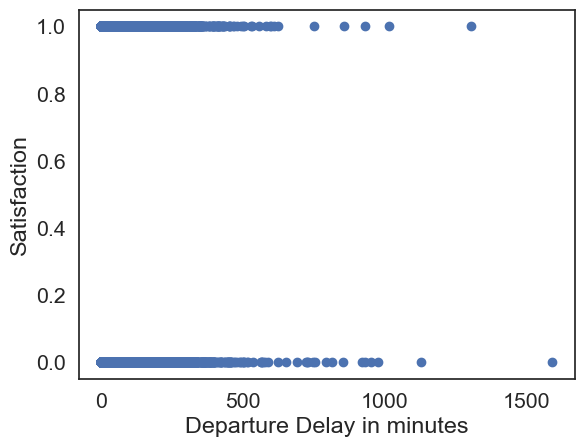

In [43]:
plt.scatter(data_test_lr['Departure_Delay_in_Minutes'], data_test_lr['satisfaction'])
plt.xlabel('Departure Delay in minutes')
plt.ylabel('Satisfaction')
plt.show()


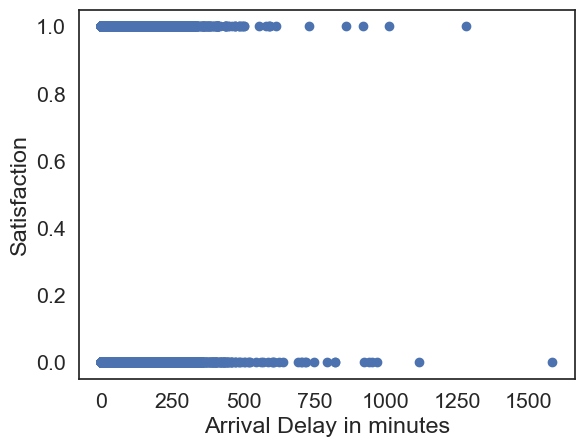

In [44]:
plt.scatter(data_test_lr['Arrival_Delay_in_Minutes'], data_test_lr['satisfaction'])
plt.xlabel('Arrival Delay in minutes')
plt.ylabel('Satisfaction')
plt.show()

In [45]:
import statsmodels.formula.api as smf

In [46]:
# convert the "satisfaction" column to a numeric data type
data_test_lr["satisfaction"] = pd.to_numeric(data_test_lr["satisfaction"], errors="coerce")


# fit the model
model = smf.ols(formula='satisfaction ~ Departure_Delay_in_Minutes + Arrival_Delay_in_Minutes', data=data_test_lr).fit()

# print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     241.2
Date:                Sat, 17 Jun 2023   Prob (F-statistic):          2.79e-105
Time:                        11:39:08   Log-Likelihood:                -92900.
No. Observations:              129880   AIC:                         1.858e+05
Df Residuals:                  129877   BIC:                         1.858e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [47]:
# fit the model
model_1 = smf.ols(formula='satisfaction ~ Arrival_Delay_in_Minutes', data=data_test_lr).fit()

# print the summary
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     440.6
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           1.17e-97
Time:                        11:39:09   Log-Likelihood:                -92920.
No. Observations:              129880   AIC:                         1.858e+05
Df Residuals:                  129878   BIC:                         1.859e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [48]:
# fit the model
model_2 = smf.ols(formula='satisfaction ~ Departure_Delay_in_Minutes', data=data_test_lr).fit()

# print the summary
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     335.2
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           8.63e-75
Time:                        11:39:10   Log-Likelihood:                -92973.
No. Observations:              129880   AIC:                         1.859e+05
Df Residuals:                  129878   BIC:                         1.860e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

## <font color='gold'>**Check for multi-collinearity**</font>
<h5>
<font color='orange'>It should be noted that we already saw that the departure delay and arrival delay per minutes columns were shown to be very correlated by using a heat map.</font>. Although correlation analysis and visualization helpful for understanding the linear relationship between pairs of variables, they may not capture the full extent of multicollinearity in a regression model. <font color='yellow'><b>Multicollinearity refers to a situation where <u>two or more predictor variables</u> in a regression model are highly correlated with each other.</b></font>

To check for multicollinearity in a dataset using Python, you can use the variance inflation factor (VIF). The VIF measures the extent to which the variance (or standard error) of the estimated regression coefficient is increased due to collinearity among the predictor variables in a linear regression model. 
</h5>

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [50]:
data_test_lr.isnull().sum()

id                                   0
Gender                               0
Customer_Type                        0
Age                                  0
Type_of_Travel                       0
Class                                0
Flight_Distance                      0
Inflight_wifi_service                0
Departure/Arrival_time_convenient    0
Ease_of_Online_booking               0
Gate_location                        0
Food_and_drink                       0
Online_boarding                      0
Seat_comfort                         0
Inflight_entertainment               0
On-board_service                     0
Leg_room_service                     0
Baggage_handling                     0
Checkin_service                      0
Inflight_service                     0
Cleanliness                          0
Departure_Delay_in_Minutes           0
Arrival_Delay_in_Minutes             0
satisfaction                         0
dtype: int64

In [51]:
X = data_test_lr[['Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']]
X.loc[:, 'Intercept'] = 1
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

C:\Users\User\AppData\Local\Temp\ipykernel_31280\270355696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.loc[:, 'Intercept'] = 1


In [52]:
X

,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,Intercept
0,25,18.0,1
1,1,6.0,1
2,0,0.0,1
3,11,9.0,1
4,0,0.0,1
...,...,...,...
129875,0,0.0,1
129876,0,0.0,1
129877,0,0.0,1
129878,0,0.0,1


In [53]:
vif

,VIF Factor,features
0,12.565103,Departure_Delay_in_Minutes
1,12.565103,Arrival_Delay_in_Minutes
2,1.154836,Intercept


Here are some conclusions that can be drawn regarding multicollinearity between the variables 'Departure_Delay_in_Minutes' and 'Arrival_Delay_in_Minutes':

1. Both 'Departure_Delay_in_Minutes' and 'Arrival_Delay_in_Minutes' have relatively high VIF factors of approximately 12.565103. VIF values above 5 or 10 are often considered indicative of significant multicollinearity. In this case, the high VIF factors suggest a strong correlation between these two variables.

2. The 'Intercept' variable has a VIF factor of 1.154836, which is relatively low. A VIF factor close to 1 indicates no multicollinearity with other variables. This is expected since the intercept represents the constant term in the regression model and is not influenced by other predictors.

3. The high VIF factors for both 'Departure_Delay_in_Minutes' and 'Arrival_Delay_in_Minutes' suggest that these variables are highly correlated with each other. This multicollinearity can pose challenges in the interpretation of regression coefficients and affect the stability and reliability of the model.

4. When two variables are highly correlated, it becomes difficult to distinguish the individual effects of each variable on the target variable. In the presence of multicollinearity, changes in one variable may be associated with changes in the other, making it challenging to determine the independent impact of each predictor.

5. To address multicollinearity, you might consider one of the following options:
   - Removing one of the correlated variables ('Departure_Delay_in_Minutes' or 'Arrival_Delay_in_Minutes') if they are redundant or highly similar in terms of the information they provide.
   - Combining the correlated variables into a single composite variable or creating new derived variables that capture the shared information.
   - Collecting additional data or exploring alternative variables that are less correlated but still relevant to your analysis.

In summary, the high VIF factors for 'Departure_Delay_in_Minutes' and 'Arrival_Delay_in_Minutes' indicate the presence of multicollinearity. Further analysis and decision-making regarding variable selection or transformation are necessary to address multicollinearity and build a more stable and reliable regression model.

<h5>
When deciding which variable to remove to address multicollinearity, there are a few factors to consider:

1. Domain Knowledge: Consider the domain or subject matter knowledge related to the variables. Evaluate which variable is more meaningful and relevant to your analysis. Think about which variable has a stronger theoretical or practical basis in explaining the outcome variable or aligns better with your research question.

2. Statistical Significance: Assess the statistical significance of each variable individually. If one variable has a more significant impact on the outcome variable compared to the other, it may be a good candidate to retain in the model. You can examine the coefficients, p-values, and confidence intervals to determine the significance of each variable.

3. Data Quality: Consider the quality and reliability of the data for each variable. If one variable has more missing values, data inconsistencies, or data quality issues, it might be preferable to remove that variable.

4. Model Performance: Evaluate the impact of removing each variable on the overall model performance. Remove one variable at a time and assess the change in model fit, goodness-of-fit measures (such as R-squared), and predictive accuracy. Choose the variable that results in the least detrimental effect on the model's performance.

5. Interpretability: Consider the interpretability and ease of understanding the model results. Select the variable that provides clearer and more intuitive interpretations of the regression coefficients. This can help in communicating and explaining the findings to others effectively.

By considering these factors, you can make an informed decision about which variable to remove. Remember to re-evaluate the model after removing one variable to ensure it still meets your requirements and objectives.</h5>

<h1>Test for Normality using QQ-Plot</h1>a

<u>**<h4>Recap on qq-plot and some of the intuition behind it.</h4>**</u>
<p>A QQ plot, short for quantile-quantile plot, is a graphical method for comparing a data distribution to a theoretical distribution. In a QQ plot, the quantiles of the two distributions are plotted against each other. If the data follows the theoretical distribution closely, the points on the plot will form a straight line. Deviations from the straight line indicate differences between the two distributions. A QQ plot can be used to visually assess whether the data follows a particular distribution, such as the normal distribution.</p>

In [54]:
arrival_delay = data_test_lr['Arrival_Delay_in_Minutes']
departure_delay = data_test_lr['Departure_Delay_in_Minutes']

In [55]:
import scipy.stats as stats

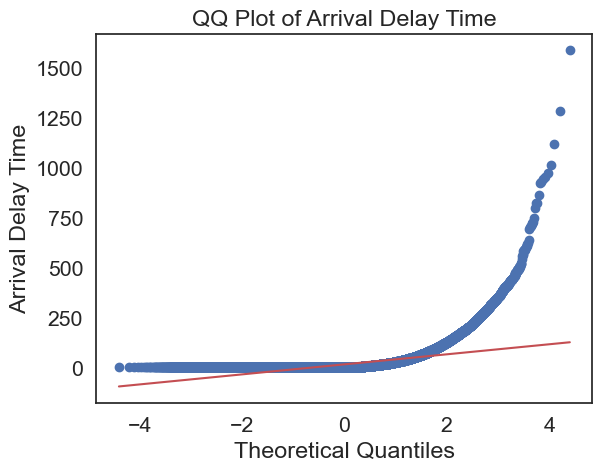

In [56]:
# Generate QQ plot for arrival delay time
stats.probplot(arrival_delay, dist="norm", plot=plt)
plt.title('QQ Plot of Arrival Delay Time')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Arrival Delay Time')
plt.show()

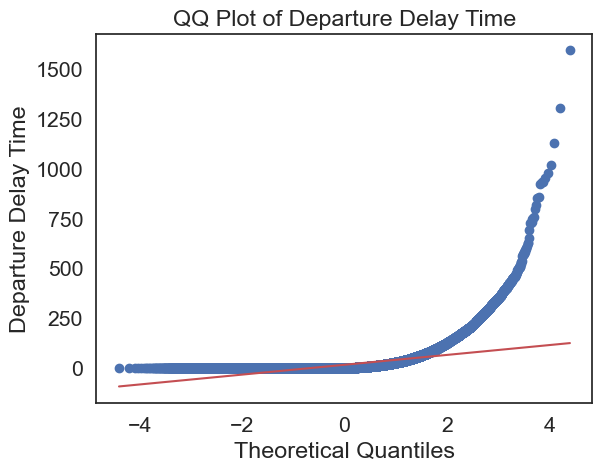

In [57]:
# Generate QQ plot for departure delay time
stats.probplot(departure_delay, dist="norm", plot=plt)
plt.title('QQ Plot of Departure Delay Time')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Departure Delay Time')
plt.show()

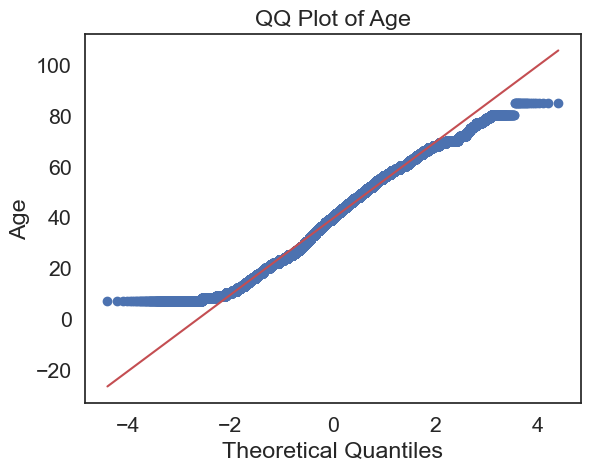

In [58]:
stats.probplot(data_test_lr['Age'], dist="norm", plot=plt)
plt.title('QQ Plot of Age')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Age')
plt.show()

 It's safe to say that the normality assumption has been broken.

### Linearity

We'll do that using a scatter plot

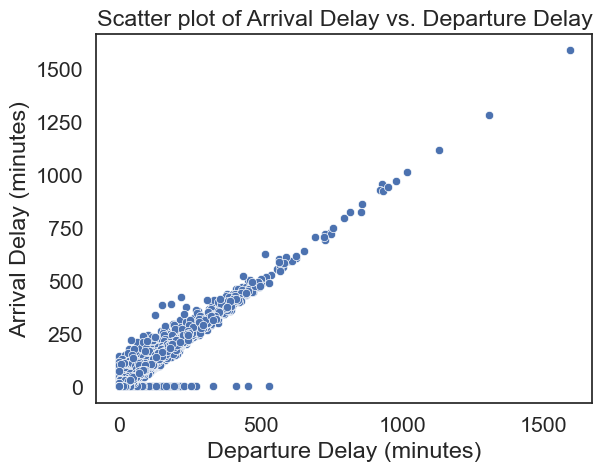

In [59]:
sns.scatterplot(x='Departure_Delay_in_Minutes', y='Arrival_Delay_in_Minutes', data=data_test_lr)

plt.title('Scatter plot of Arrival Delay vs. Departure Delay')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Arrival Delay (minutes)')
plt.show()

There seems to be a linear relationship between arrival delay and departure delay. We will have to remove one of them.We will have to consider other factors such as the correlation of each variable with the response variable (if you have one), potential confounding variables, and the overall fit and interpretability of your model. Additionally, you could also try including both variables in the model and see if they both contribute significantly to the model's predictive power.


___________________________________Still updating_____________________________________________

### Independence

In [60]:
data_test_lr.head()

,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


### Homoscedasticity

In [61]:
import statsmodels.api as sm

def plot_residuals(feature):
    # Create a copy of the DataFrame
    data = data_test_lr.copy()
    
    # Prepare the data
    X = data[[feature]]
    y = data['satisfaction']
    X = sm.add_constant(X)  # Add a constant column for the intercept
    
    # Fit the regression model
    model = sm.OLS(y, X).fit()
    
    # Calculate residuals
    residuals = model.resid
    
    # Plot residuals against predicted values
    plt.scatter(model.fittedvalues, residuals)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot for {feature}')
    plt.show()

In [62]:
data_columns = ['Age', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']

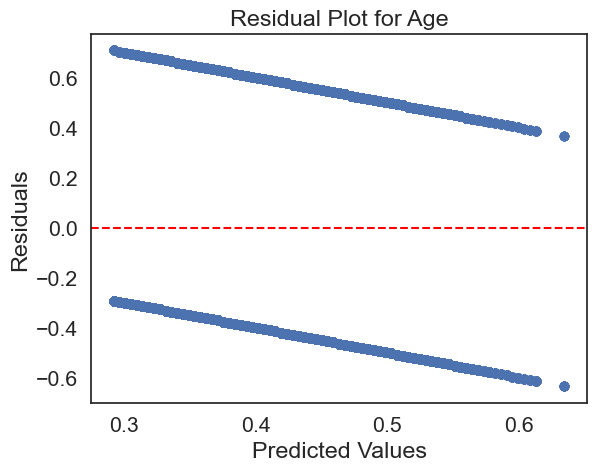

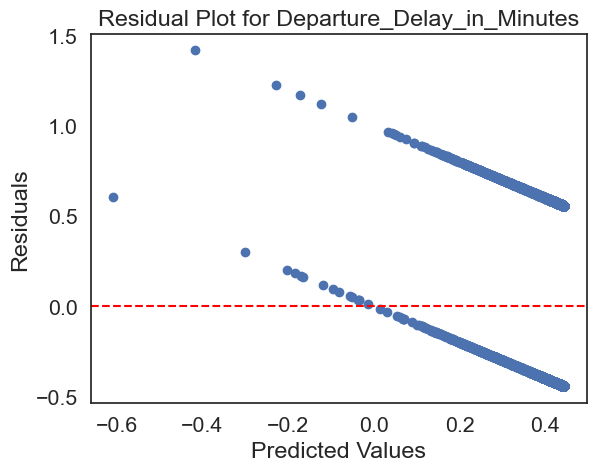

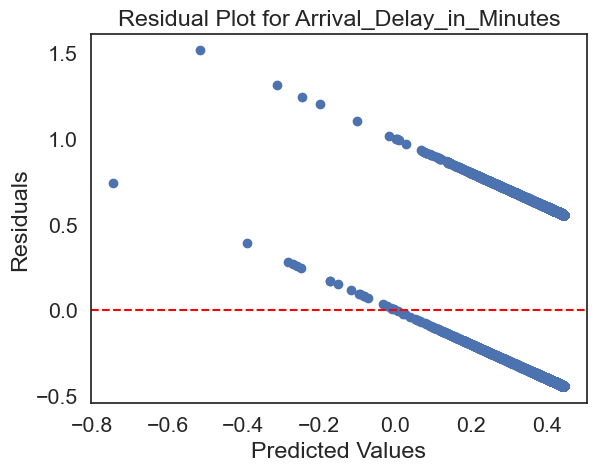

In [63]:
for c in data_columns:
    plot_residuals(c)

<h5>It is clear that there is a pattern to all the residual plots above and thus the homoscedasticity assumption is violated further on confirming our effort to just leave the linear regression model and focus on the non-linear one instead, in our case, the logistic model.</h5>

Satisfied -> no churn  
Dis or neutral -> churn(leave)

In [25]:
Union

['Age',
 'Cleanliness',
 'Inflight_entertainment',
 'Customer_Type',
 'On-board_service',
 'id',
 'Ease_of_Online_booking',
 'Online_boarding',
 'Seat_comfort',
 'Checkin_service',
 'Type_of_Travel',
 'Departure_Delay_in_Minutes',
 'Arrival_Delay_in_Minutes',
 'Baggage_handling',
 'Inflight_wifi_service',
 'Flight_Distance',
 'Class',
 'Leg_room_service',
 'Inflight_serice']

In [27]:
features

['Inflight_wifi_service',
 'Online_boarding',
 'Seat_comfort',
 'Inflight_entertainment',
 'Leg_room_service',
 'Inflight_service',
 'Class']

In [26]:
features = ['Inflight_wifi_service','Online_boarding','Seat_comfort',
            'Inflight_entertainment','Leg_room_service',
            'Inflight_service', 'Class']
target = ['satisfaction']

# <font color='red'><u>**Model Creation & Evaluation**</u></font>

<h5>When splitting data for training machine learning algorithms, it is generally recommended to use the same split each time for consistent evaluation and comparison of models</h5>


In [198]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### <font color='yellow'>**This is our evaluation function**

In [94]:
import time
import scikitplot as skplt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

def run_model(model, X_train, y_train, X_test, y_test, verbose=True):
    t0 = time.time()
    if not verbose:
        model.fit(X_train, y_train.ravel(), verbose=0)
    else:
        model.fit(X_train, y_train.ravel())
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    time_taken = time.time() - t0
    print("Accuracy = {}".format(accuracy))
    print("ROC Area under Curve = {}".format(roc_auc))
    print("Time taken = {}".format(time_taken))
    print(classification_report(y_test, y_pred, digits=5))
    
    skplt.metrics.plot_confusion_matrix(y_test, y_pred, normalize=True, cmap=plt.cm.pink)
    classes_to_plot = list(set(y_test))  # Exclude micro-average class index
    skplt.metrics.plot_roc(y_test, model.predict_proba(X_test), classes_to_plot=classes_to_plot, plot_micro=False)
    
    return model, accuracy, roc_auc, time_taken

In [139]:
import time
import scikitplot as skplt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def run_model_1(model, X_train, y_train, X_test, y_test, verbose=True):
    t0 = time.time()
    if not verbose:
        model.fit(X_train, y_train.ravel(), verbose=0)
    else:
        model.fit(X_train, y_train.ravel())
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    time_taken = time.time() - t0
    print("Accuracy = {}".format(accuracy))
    print("ROC Area under Curve = {}".format(roc_auc))
    print("Time taken = {} seconds".format(time_taken))
    print(classification_report(y_test, y_pred, digits=5))
    
    # Calculate TN, TP, FP, FN
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    confusion_matrix_values = [[tn, fp], [fn, tp]]
    skplt.metrics.plot_confusion_matrix(y_test, y_pred, normalize=True, cmap=plt.cm.Greens)
    
    # Add values of TN, TP, FP, FN to the confusion matrix plot
    plt.text(0, 0, "TN = {}\nFP = {}\nFN = {}\nTP = {}".format(tn, fp, fn, tp), color='black',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=12)
    
    classes_to_plot = list(set(y_test))  # Exclude micro-average class index
    skplt.metrics.plot_roc(y_test, model.predict_proba(X_test), classes_to_plot=classes_to_plot, plot_micro=False)
    
    return model, accuracy, roc_auc, time_taken


### <font color='turquoise'>**Model-0: Linear Regression**</font>

In [144]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [199]:
# Create and train the linear regression model
model_0 = LinearRegression()
model_0.fit(X_train, y_train)

# Predict on the test set
y_pred = model_0.predict(X_test)

# Calculate the test score (R-squared)
test_score = r2_score(y_test, y_pred)

# Print the test score
print("Test Score (R-squared):", test_score)

# Get the feature coefficients
feature_coefficients = model_0.coef_.tolist()
features = X.columns
D = {}

Test Score (R-squared): 0.5504614421337664


In [201]:
feature_coefficients

[-4.068727828198676e-07,
 0.009410196335645318,
 -0.3178884591160339,
 -0.0009496364875129632,
 -0.4030880342679367,
 -0.08578250837183836,
 5.309841977286889e-06,
 0.06607589363776749,
 -0.01689629974981316,
 -0.041606946172833996,
 0.0043219164147309365,
 -0.004327209019582896,
 0.08075290438312964,
 0.010080650616427819,
 0.01274888251966335,
 0.03655973703374375,
 0.03277771124259006,
 0.01773267641229581,
 0.03836806594249107,
 0.01609641734554455,
 0.026052799203006228,
 0.000519378777583331,
 -0.001046607893432702]

In [186]:
model_0.coef_

array([-4.63145744e-07,  8.33183502e-03, -3.21480841e-01, -9.49635000e-04,
       -4.02558140e-01, -8.41515702e-02,  5.33429784e-06,  6.66029339e-02,
       -1.70200087e-02, -4.04896068e-02,  3.00782713e-03, -4.25377509e-03,
        8.10871920e-02,  9.37239611e-03,  1.26993298e-02,  3.52459056e-02,
        3.30862167e-02,  1.84075329e-02,  3.85850989e-02,  1.68659163e-02,
        2.57389238e-02,  4.80654958e-04, -1.00090110e-03])

### Important !!

<h5>Here is an example generated and how you guys can interpret each metric to guage our logistic model. Remember that </h5>

In [253]:
from sklearn.metrics import classification_report

In [254]:
# Split the data into training and testing sets
X_train10, X_test10, y_train10, y_test10 = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the logistic regression model
model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_train10, y_train10)

# Make predictions on the test set
y_pred10 = model_all.predict(X_test10)


# Get the coefficients and intercept
coefficients = model_all.coef_
intercept = model_all.intercept_



# Generate the classification report
report = classification_report(y_test10, y_pred10)

# Print the classification report
print(report)

              precision    recall  f1-score   support

           0       0.80      0.79      0.79     14622
           1       0.73      0.75      0.74     11354

    accuracy                           0.77     25976
   macro avg       0.77      0.77      0.77     25976
weighted avg       0.77      0.77      0.77     25976



<h5>
The classification report provides detailed evaluation metrics for each class in the binary classification problem. Here's a breakdown of the metrics in the classification report:

Precision:
- Precision for class 0 (dissatisfied or neutral): The precision is 0.80, which means that out of all the instances predicted as class 0, 80% were correctly classified as dissatisfied or neutral.
- Precision for class 1 (satisfied): The precision is 0.73, indicating that 73% of the instances predicted as class 1 were correctly classified as satisfied.

Recall:
- Recall for class 0: The recall is 0.79, which means that out of all the actual instances of dissatisfied or neutral customers, 79% were correctly identified.
- Recall for class 1: The recall is 0.75, indicating that 75% of the actual instances of satisfied customers were correctly identified.

F1-score:
- F1-score for class 0: The F1-score is 0.79, which is the harmonic mean of precision and recall for class 0. It provides a balanced measure of the model's performance in correctly identifying dissatisfied or neutral customers.
- F1-score for class 1: The F1-score is 0.74, representing the harmonic mean of precision and recall for class 1. It provides a balanced measure of the model's performance in correctly identifying satisfied customers.

Support:
- Support for class 0: The support is 14,622, which indicates the number of instances in the test set that belong to class 0 (dissatisfied or neutral).
- Support for class 1: The support is 11,354, representing the number of instances in the test set that belong to class 1 (satisfied).

Accuracy:
- Accuracy: The overall accuracy of the model is 0.77, which means that 77% of the instances in the test set were correctly classified.

Macro Average:
- The macro average takes the average of precision, recall, and F1-score across all classes. In this case, the macro average precision, recall, and F1-score are all 0.77.

Weighted Average:
- The weighted average calculates the metrics by weighting them based on the support of each class. It provides an overall measure of the model's performance, considering the class imbalance. The weighted average precision, recall, and F1-score are all 0.77.

In summary, the classification report shows that the model has reasonably good performance with a balanced F1-score for both classes. The model achieved an accuracy of 0.77, indicating that it correctly classified 77% of the instances. However, it's important to consider the specific requirements of your application and compare these metrics against a baseline or other models to assess if further improvement is needed.
</h5>

In [98]:
feature_names = X.columns

print("Coefficients:")
for feature, coefficient in zip(feature_names, coefficients[0]):
    print(f"{feature}: {coefficient}")

print("Intercept:")
print(intercept)

Coefficients:
id: -8.77949259170884e-06
Gender: -0.05329256896409193
Customer_Type: -0.12585558656578885
Age: -0.01805182471211326
Type_of_Travel: -0.32062956878932497
Class: -0.43242148880519066
Flight_Distance: 0.00032179498457151896
Inflight_wifi_service: 0.18445466660556634
Departure/Arrival_time_convenient: -0.4435514005636447
Ease_of_Online_booking: -0.02516177920990662
Gate_location: -0.33934401584557944
Food_and_drink: -0.08779605368759812
Online_boarding: 0.5026284816406886
Seat_comfort: 0.1458082466371974
Inflight_entertainment: 0.23028230886904183
On-board_service: 0.12924939637213084
Leg_room_service: 0.12011386120096997
Baggage_handling: -0.0664844086106489
Checkin_service: 0.008658291065319406
Inflight_service: -0.08261523103598355
Cleanliness: 0.07545904792753348
Departure_Delay_in_Minutes: 0.0054804680458038334
Arrival_Delay_in_Minutes: -0.011108956948422991
Intercept:
[-0.12987788]


### <font color='turquoise'>**Model-1: Normal Logistic Regression(all features)**</font>

In [135]:
from sklearn.linear_model import LogisticRegression

In [255]:
# Create a logistic regression model
model_1 = LogisticRegression(C=1e100)

# Train the model
model_1.fit(X_train, y_train)

LogisticRegression(C=1e+100)

Accuracy = 0.6824761318139821
ROC Area under Curve = 0.6834127836644018
Time taken = 0.9849996566772461 seconds
              precision    recall  f1-score   support

           0    0.73794   0.67597   0.70560     14622
           1    0.62343   0.69086   0.65541     11354

    accuracy                        0.68248     25976
   macro avg    0.68069   0.68341   0.68051     25976
weighted avg    0.68789   0.68248   0.68366     25976



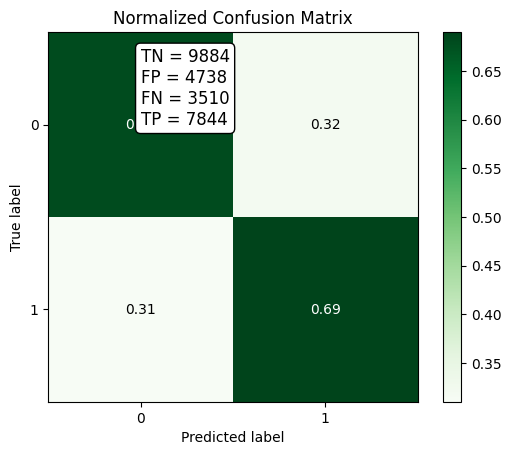

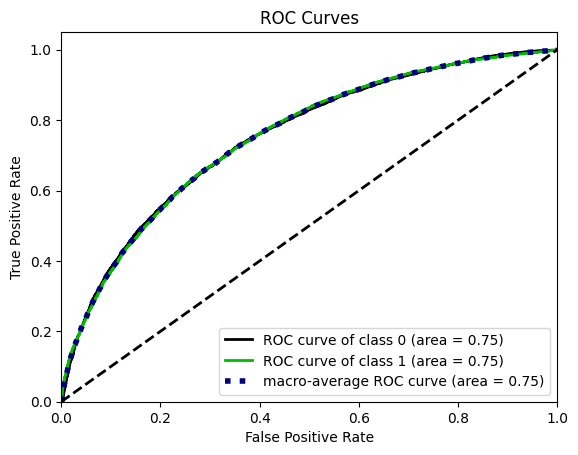

In [256]:
model_1, accuracy_1, roc_auc_1, tt_1 = run_model(model_1, X_train, y_train, X_test, y_test)

### <b>Traininig unregularized logistic regression on lists of features selected</b>

In [263]:
def train_unregularized_logistic_models(model, features):
    # Select the specified features from the training and test sets
    X_train_selected = X_train[features].copy()
    X_test_selected = X_test[features].copy()

    # Create and train the logistic regression model
    model_log = model
    model_log.fit(X_train_selected, y_train)

    # Predict on the test set
    y_pred = model_log.predict(X_test_selected)
    run_model_1(model_log, X_train_selected, y_train, X_test_selected, y_test)
    return model_log

In [264]:
lists_of_features_selected = [
    chi_sq, decision_tree, random_forest, permutation_features, RFE, backward, forward, stepwise
]
names = ['chi_square', 'decision_tree', 'random_forest', 'permutation', 'RFE', 'backward', 'forward', 'stepwise']

--------------------------------
Information for chi_square
--------------------------------
Accuracy = 0.8637203572528488
ROC Area under Curve = 0.8596192605113845
Time taken = 0.4120302200317383 seconds
              precision    recall  f1-score   support

           0    0.86915   0.89222   0.88053     14622
           1    0.85628   0.82702   0.84140     11354

    accuracy                        0.86372     25976
   macro avg    0.86272   0.85962   0.86097     25976
weighted avg    0.86353   0.86372   0.86343     25976

--------------------------------
Information for decision_tree
--------------------------------
Accuracy = 0.8458577148136741
ROC Area under Curve = 0.8408492809233649
Time taken = 0.11203122138977051 seconds
              precision    recall  f1-score   support

           0    0.85075   0.88066   0.86545     14622
           1    0.83902   0.80104   0.81959     11354

    accuracy                        0.84586     25976
   macro avg    0.84489   0.84085   0.842

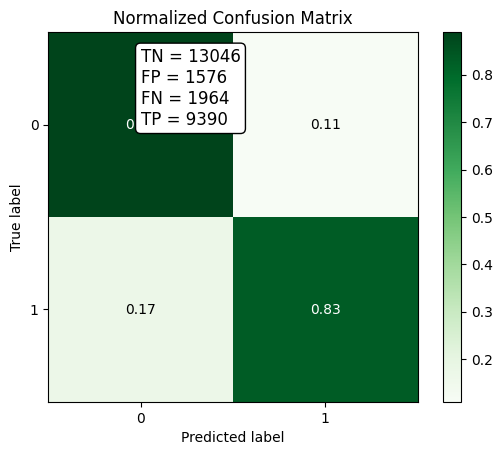

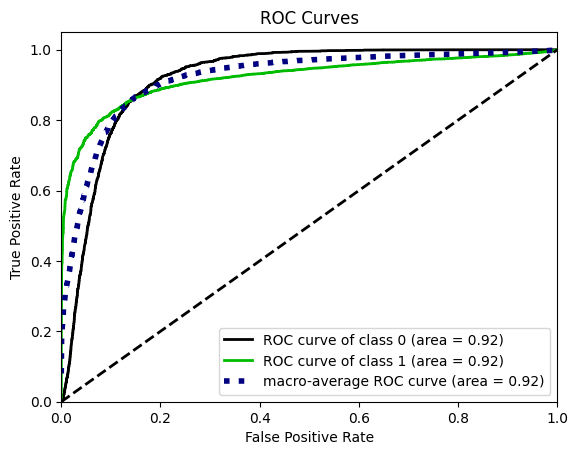

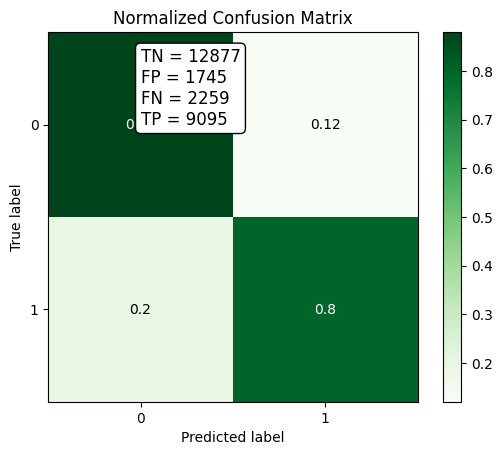

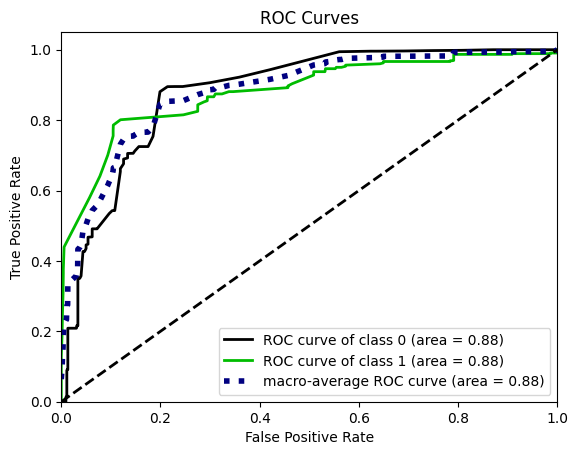

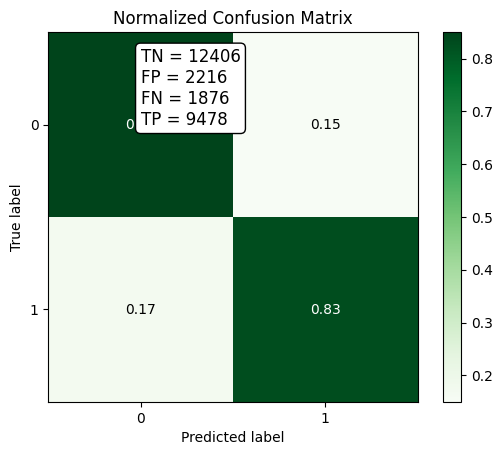

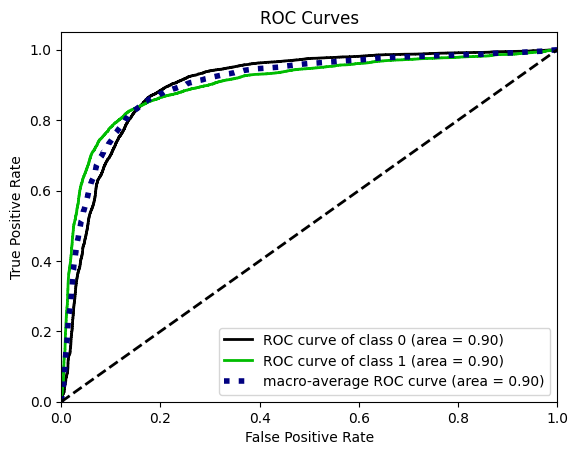

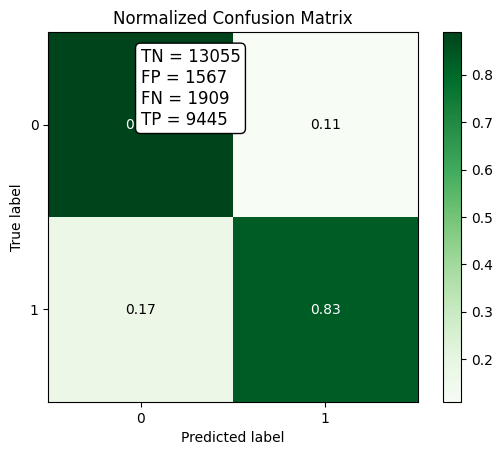

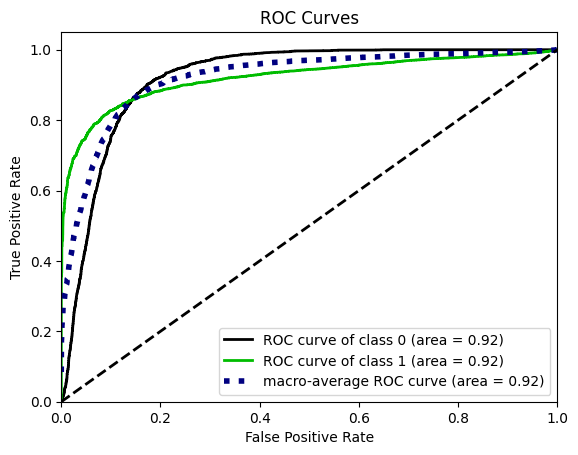

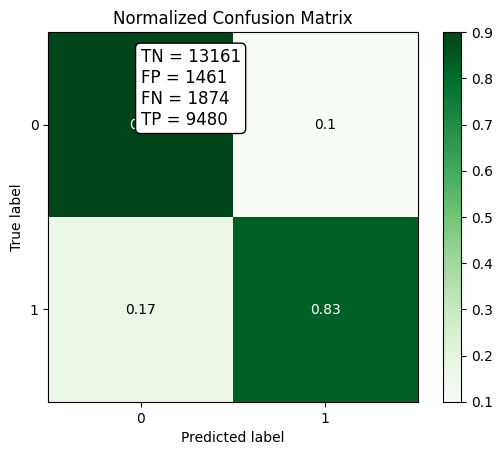

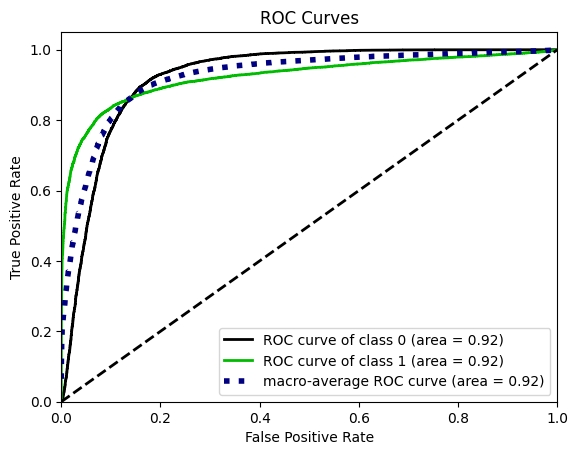

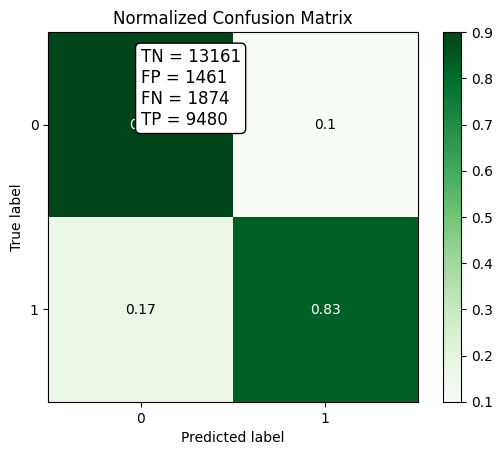

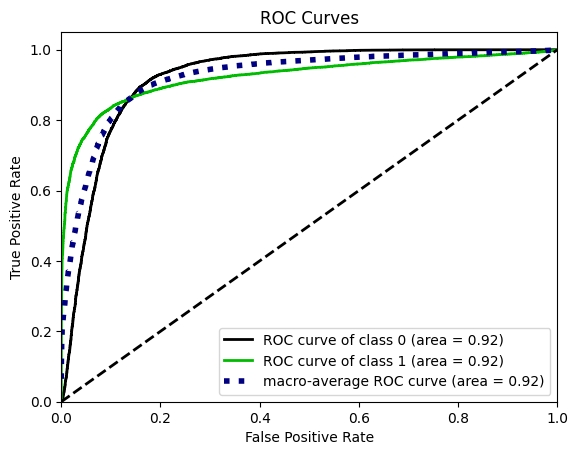

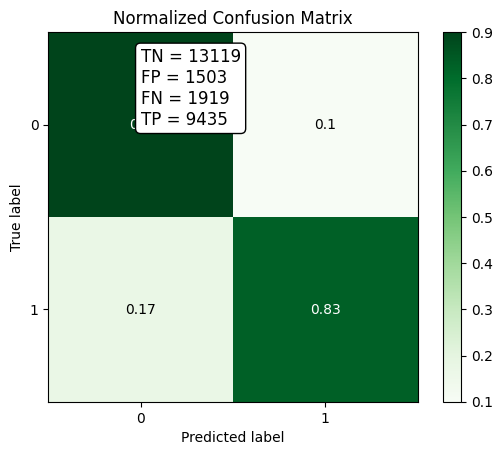

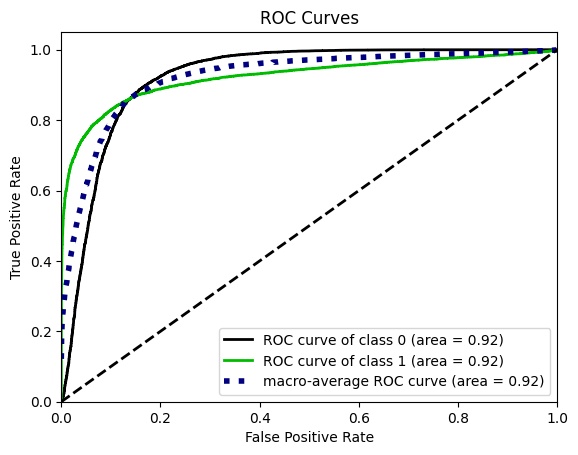

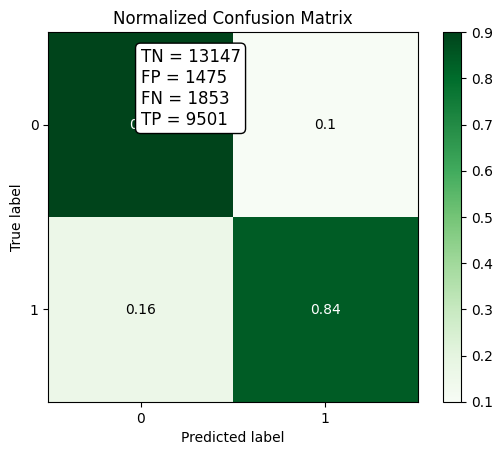

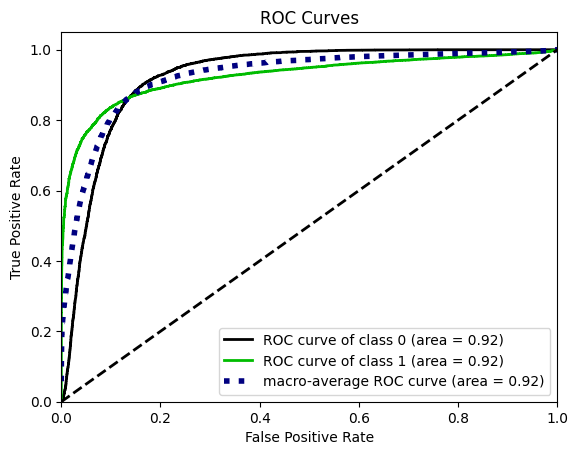

In [266]:
M_unregularized = []
for i in range(len(lists_of_features_selected)):
    print("--------------------------------")
    print(f"Information for {names[i]}")
    print("--------------------------------")
    M_unregularized.append(    train_unregularized_logistic_models(model=LogisticRegression(C=1e10), features=lists_of_features_selected[i]))

In [268]:
M_unregularized[0]

LogisticRegression(C=10000000000.0)

#### <font color='orange'>**Model-2: Logistic Regression penalized with Lasso (regularization_strength = 0.1)**</font>

Accuracy = 0.8760009239297813
ROC Area under Curve = 0.8720924059236209
Time taken = 1.4579730033874512 seconds
              precision    recall  f1-score   support

           0    0.87975   0.90316   0.89130     14622
           1    0.87086   0.84103   0.85568     11354

    accuracy                        0.87600     25976
   macro avg    0.87531   0.87209   0.87349     25976
weighted avg    0.87587   0.87600   0.87573     25976



(LogisticRegression(C=0.1, penalty='l1', solver='liblinear'),
 0.8760009239297813,
 0.8720924059236209,
 1.4579730033874512)

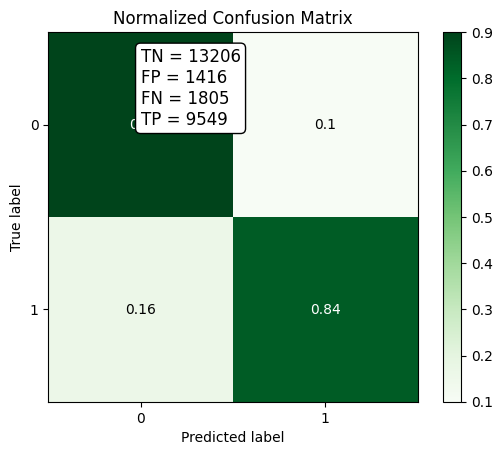

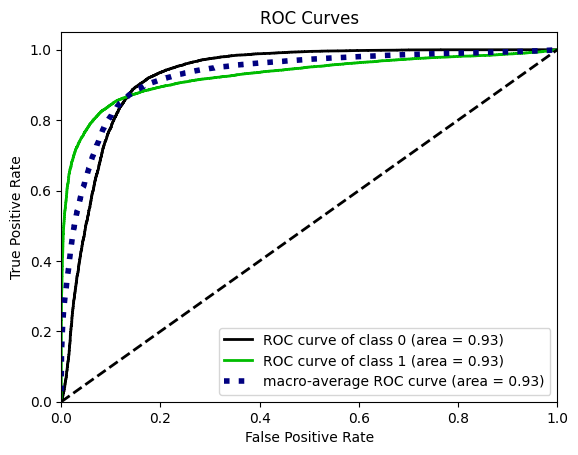

In [238]:
model_2 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
model_2.fit(X_train, y_train)
run_model_1(model_2, X_train, y_train, X_test, y_test)

#### <font color='orange'>**Model-3: Logistic Regression penalized with Ridge (L2 penalty = 50%)**</font>

Accuracy = 0.8503618724976901
ROC Area under Curve = 0.8483539586638543
Time taken = 2.2230007648468018 seconds
              precision    recall  f1-score   support

           0    0.86913   0.86431   0.86671     14622
           1    0.82650   0.83239   0.82944     11354

    accuracy                        0.85036     25976
   macro avg    0.84781   0.84835   0.84807     25976
weighted avg    0.85049   0.85036   0.85042     25976



(LogisticRegression(C=0.1, solver='liblinear'),
 0.8503618724976901,
 0.8483539586638543,
 2.2230007648468018)

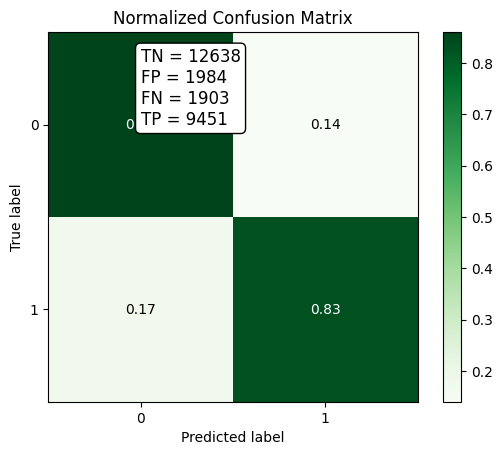

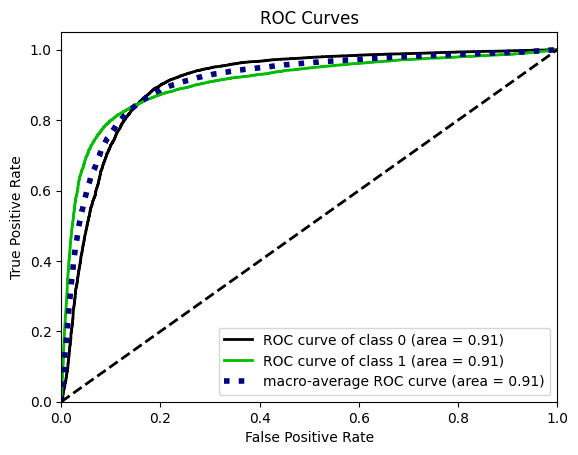

In [241]:
model_3 = LogisticRegression(penalty='l2', solver='liblinear', C=0.1)
model_3.fit(X_train, y_train)
run_model_1(model_3, X_train, y_train, X_test, y_test)

#### <font color='orange'>**Model-4: Logistic Regression penalized with Elastic Net (L1 penalty = 50%, L2 penalty = 50%)**</font>

Accuracy = 0.6131429011395134
ROC Area under Curve = 0.600696093611141
Time taken = 7.519938230514526 seconds
              precision    recall  f1-score   support

           0    0.64392   0.69963   0.67062     14622
           1    0.56467   0.50176   0.53136     11354

    accuracy                        0.61314     25976
   macro avg    0.60430   0.60070   0.60099     25976
weighted avg    0.60928   0.61314   0.60975     25976



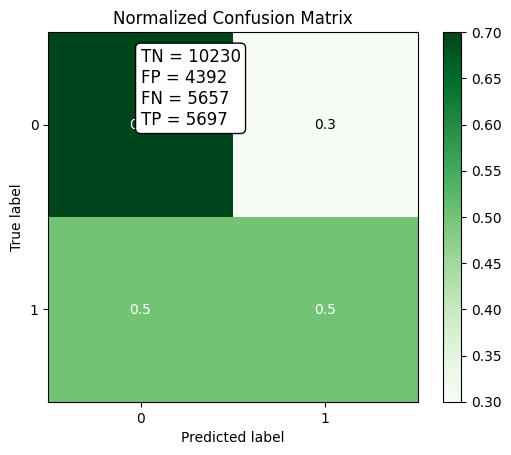

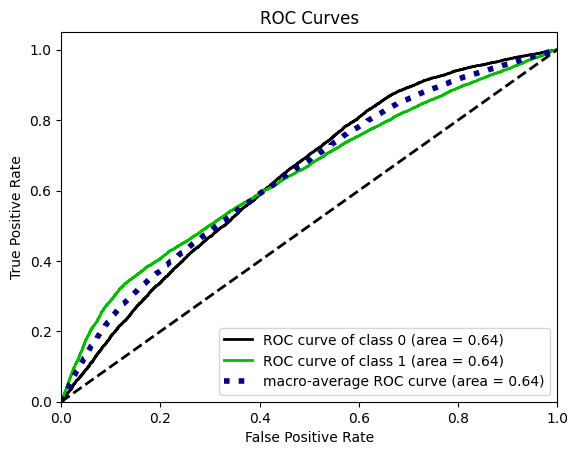

In [248]:
params_lr = {'penalty': 'elasticnet', 'l1_ratio':0.6, 'solver': 'saga'}

model_lr = LogisticRegression(**params_lr, C=0.01)
model_lr, accuracy_lr, roc_auc_lr, tt_lr = run_model_1(model_lr, X_train, y_train, X_test, y_test)

### <font color='gold'>**Model-5: Decision Tree**</font>

In [250]:
from sklearn.tree import DecisionTreeClassifier

Accuracy = 0.9471820141669233
ROC Area under Curve = 0.9459782563100856
Time taken = 0.8245549201965332 seconds
              precision    recall  f1-score   support

           0    0.95086   0.95555   0.95320     14622
           1    0.94239   0.93641   0.93939     11354

    accuracy                        0.94718     25976
   macro avg    0.94663   0.94598   0.94629     25976
weighted avg    0.94716   0.94718   0.94716     25976



(DecisionTreeClassifier(),
 0.9471820141669233,
 0.9459782563100856,
 0.8245549201965332)

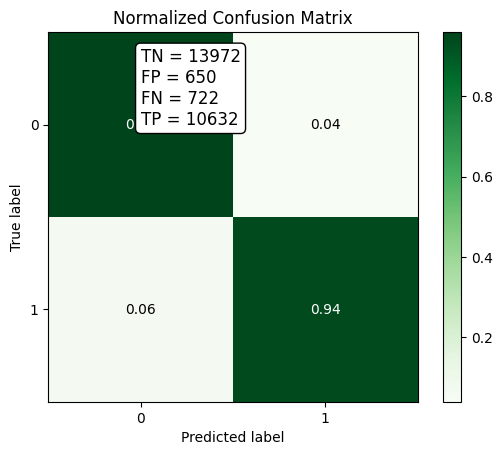

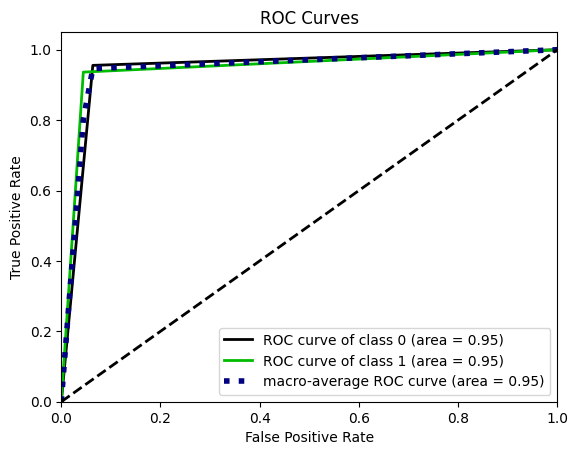

In [251]:
# Create a decision tree classifier
model_5 = DecisionTreeClassifier()

# Train the model
model_5.fit(X_train, y_train)
run_model_1(model_5, X_train, y_train, X_test, y_test)

### <font color='gold'>**Model-6: Random Forest**</font>

Accuracy = 0.9615414228518633
ROC Area under Curve = 0.9589396976191548
Time taken = 14.038161754608154 seconds
              precision    recall  f1-score   support

           0    0.95334   0.97962   0.96630     14622
           1    0.97279   0.93826   0.95521     11354

    accuracy                        0.96154     25976
   macro avg    0.96307   0.95894   0.96076     25976
weighted avg    0.96184   0.96154   0.96146     25976



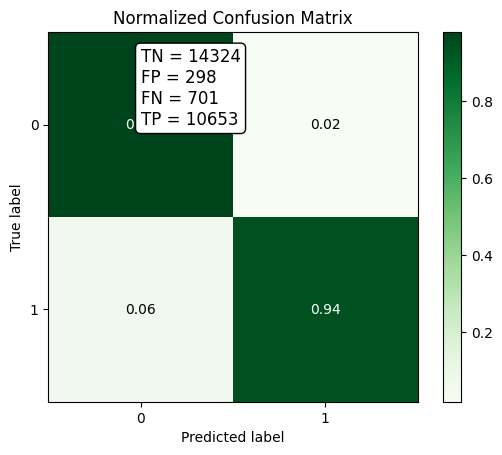

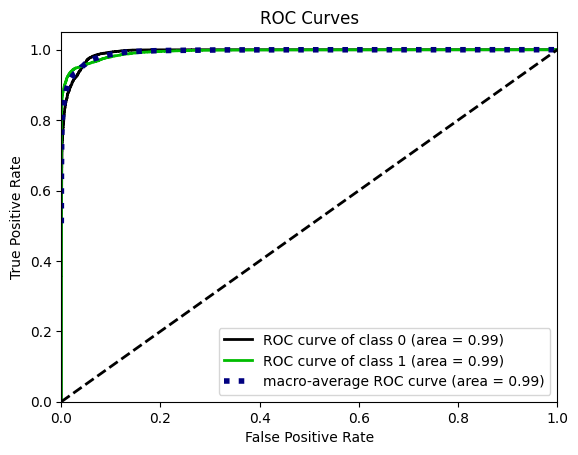

In [234]:
from sklearn.ensemble import RandomForestClassifier

params_rf = {'max_depth': 16,
             'min_samples_leaf': 1,
             'min_samples_split': 2,
             'n_estimators': 100,
             'random_state': 12345}

model_rf = RandomForestClassifier(**params_rf)
model_rf, accuracy_rf, roc_auc_rf, tt_rf = run_model_1(model_rf, X_train, y_train, X_test, y_test)